1
(1, 120)


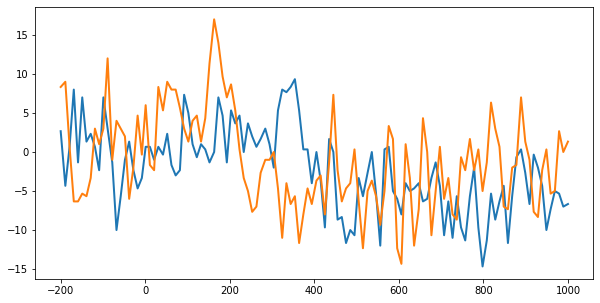

In [12]:
import matplotlib.pyplot as plt

data_darray = np.expand_dims(decAcc_u, axis=0) * 100 - 50 
fig, ax = plt.subplots(figsize=(10, 5))

n_subjects, n_imgs, _, n_time, _ = data_darray.shape
print(n_subjects)
data_darray = data_darray[:, :, :, np.arange(n_time), np.arange(n_time)]  # get only diagonal
time = np.linspace(-200, 1000, n_time).astype(int)

short_ISI = data_darray[:, 0:4, 0:4, :]
long_ISI = data_darray[:, 4:8, 4:8, :]

short_ISI_avg = np.nanmean(short_ISI, axis=(1, 2))
long_ISI_avg = np.nanmean(long_ISI, axis=(1, 2))
print(long_ISI_avg.shape)

short_ISI_sem = np.std(short_ISI_avg, axis=0) / np.sqrt(n_subjects)
long_ISI_sem = np.std(long_ISI_avg, axis=0) / np.sqrt(n_subjects)

short_ISI_grandAvg = np.nanmean(short_ISI_avg, axis=0)
long_ISI_grandAvg = np.nanmean(long_ISI_avg, axis=0)

ax.plot(time, short_ISI_grandAvg, label='0.017', linewidth=2)
ax.fill_between(time, short_ISI_grandAvg - short_ISI_sem, short_ISI_grandAvg + short_ISI_sem, alpha=0.3)
ax.plot(time, long_ISI_grandAvg, label='0.1', linewidth=2)
ax.fill_between(time, long_ISI_grandAvg - long_ISI_sem, long_ISI_grandAvg + long_ISI_sem, alpha=0.3)

In [ ]:
def decode_neutral(sub, epoched_ver="cue", imgPerm=10, testsize=0.2, group_size=4, 
                   whitening=False, TempGen=False, model='lda'):
    """
    Pairwise decoding on neutral pseudotrials with cross-validation.
    Trains and tests on neutral trials only.

    Returns
    -------
    decAcc : ndarray, shape (n_conditions, n_conditions, n_time, n_time)
    """

    # ------------------------------------------------------------------
    # Select classifier
    # ------------------------------------------------------------------
    if model == "lda":
        CLASSIFIER = LinearDiscriminantAnalysis()
    if model == "svm":
        CLASSIFIER = LinearSVC(dual=True, penalty='l2', loss='hinge', C=1.0, max_iter=10000)

    # ------------------------------------------------------------------
    # Load data
    # ------------------------------------------------------------------
    if epoched_ver == "cue":
        subject_path = os.path.join(PATH, "eeg_epoched", f"eeg_MaskExp_{sub:04d}_cue_target.pickle")
    else:
        subject_path = os.path.join(PATH, "eeg_epoched", f"eeg_MaskExp_{sub:04d}.pickle")

    subject_data = load_data(subject_path)
    ids_ = subject_data["ids"]
    eeg_ = subject_data["eeg"]

    n_conditions = len(np.unique(ids_)) // 3
    _, n_sensors, n_time = eeg_.shape

    decAcc = np.full((n_conditions, n_conditions, n_time, n_time), np.nan)
    indexes = np.arange(n_conditions)

    n, _, _ = extract_expectations(eeg_, ids_)

    # ------------------------------------------------------------------
    # Image permutation loop
    # ------------------------------------------------------------------
    for _ in tqdm(range(imgPerm), desc="Image permutations"):

        pstrials, pk = pseudotrials_general(n, trial_num=n.shape[1])

        n_conditions, n_pstrials, n_sensors, n_time = pstrials.shape
        n_test = int(n_pstrials * testsize)
        cvs = int(n_pstrials / n_test)
        ps_ixs = np.arange(n_pstrials)

        for cv in tqdm(range(cvs), desc="Cross-Validation"):

            test_ix = np.arange(n_test) + (cv * n_test)
            train_ix = np.delete(ps_ixs.copy(), test_ix)

            ps_train = pstrials[:, train_ix, :, :]
            ps_test  = pstrials[:, test_ix,  :, :]

            for start in range(0, n_conditions, group_size):

                group = indexes[start:start + group_size]

                if whitening:
                    ps_train_w, ps_test_w = mvnn(ps_train[group], ps_test[group], group_size, n_sensors, n_time)
                else:
                    ps_train_w = ps_train[group]
                    ps_test_w  = ps_test[group]

                for i, cA in enumerate(group):
                    for cB in group[i + 1:]:
                        for t in range(n_time):

                            train_x = np.array([
                                ps_train_w[cA % group_size, :, :, t],
                                ps_train_w[cB % group_size, :, :, t]
                            ])
                            train_x = np.reshape(train_x, (len(train_ix) * 2, n_sensors))
                            train_y = np.array([1] * len(train_ix) + [2] * len(train_ix))

                            test_x = np.array([
                                ps_test_w[cA % group_size],
                                ps_test_w[cB % group_size]
                            ])
                            test_x = np.reshape(test_x, (len(test_ix) * 2, n_sensors, n_time))
                            test_y = np.array([1] * len(test_ix) + [2] * len(test_ix))

                            classifier = CLASSIFIER
                            classifier.fit(train_x, train_y)

                            for tt in (range(n_time) if TempGen else [t]):
                                pred_y    = classifier.predict(test_x[:, :, tt])
                                acc_score = accuracy_score(test_y, pred_y)
                                decAcc[cA, cB, t, tt] = np.nansum([decAcc[cA, cB, t, tt], acc_score])

    decAcc /= (cvs * imgPerm)

    save_dir = os.path.join(PATH, "eeg_decoding", epoched_ver, model)
    os.makedirs(save_dir, exist_ok=True)
    np.save(os.path.join(save_dir, f"eeg_decoding_neutral_{sub:04d}_Match_raw.npy"), decAcc)

    return decAcc

In [6]:
### Decoding
from sklearn.svm import LinearSVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score
from tqdm import tqdm 

### Local
from ExpAtt.data_helpers import dump_data, load_data
from MaskExp.data_helpers import *
from ExpAtt.decoding_pstrials import pseudotrials_general
from ExpAtt.decoding_mvnn import apply_sigma, estimate_sigma, mvnn



PATH = "/projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/"
model = "lda"
epoched_ver = "cue"
testsize = 0.2
sub = 20
imgPerm = 1
TempGen = False
whitening = False 
group_size = 2

# ------------------------------------------------------------------
# Select classifier
# ------------------------------------------------------------------
if model == "lda":
    CLASSIFIER = LinearDiscriminantAnalysis()
if model == "svm":
    CLASSIFIER = LinearSVC(dual=True, penalty='l2', loss='hinge', C=1.0, max_iter=10000)

# ------------------------------------------------------------------
# Load data
# ------------------------------------------------------------------
if epoched_ver == "cue":
    subject_path = os.path.join(PATH, "eeg_epoched", f"eeg_MaskExp_{sub:04d}_cue_target.pickle")
else:
    subject_path = os.path.join(PATH, "eeg_epoched", f"eeg_MaskExp_{sub:04d}.pickle")

subject_data = load_data(subject_path)
ids_ = subject_data["ids"]
eeg_ = subject_data["eeg"]

n_conditions = len(np.unique(ids_)) // 3
_, n_sensors, n_time = eeg_.shape

decAcc = np.full((n_conditions, n_conditions, n_time, n_time), np.nan)
indexes = np.arange(n_conditions)

n, _, _ = extract_expectations(eeg_, ids_)

### condition averages
neut_trials = n.shape[1]
pstrials, pk = pseudotrials_general(n, trial_num=neut_trials)

n_conditions, n_pstrials, n_sensors, n_time = pstrials.shape
pstrials = pstrials.reshape(4, 2, n_pstrials, n_sensors, n_time).mean(axis=1)
n_conditions, n_pstrials, n_sensors, n_time = pstrials.shape
n_test = int(n_pstrials * testsize)
cvs = int(n_pstrials / n_test)
ps_ixs = np.arange(n_pstrials)


for cv in tqdm(range(cvs), desc="Cross-Validation"):

    test_ix = np.arange(n_test) + (cv * n_test)
    train_ix = np.delete(ps_ixs.copy(), test_ix)

    ps_train = pstrials[:, train_ix, :, :]
    ps_test  = pstrials[:, test_ix,  :, :]

    for start in range(0, n_conditions, group_size):

        group = indexes[start:start + group_size]

        if whitening:
            ps_train_w, ps_test_w = mvnn(ps_train[group], ps_test[group], group_size, n_sensors, n_time)
        else:
            ps_train_w = ps_train[group]
            ps_test_w  = ps_test[group]

        for i, cA in enumerate(group):
            for cB in group[i + 1:]:
                for t in range(n_time):

                    train_x = np.array([
                        ps_train_w[cA % group_size, :, :, t],
                        ps_train_w[cB % group_size, :, :, t]
                    ])
                    train_x = np.reshape(train_x, (len(train_ix) * 2, n_sensors))
                    train_y = np.array([1] * len(train_ix) + [2] * len(train_ix))

                    test_x = np.array([
                        ps_test_w[cA % group_size],
                        ps_test_w[cB % group_size]
                    ])
                    test_x = np.reshape(test_x, (len(test_ix) * 2, n_sensors, n_time))
                    test_y = np.array([1] * len(test_ix) + [2] * len(test_ix))

                    classifier = CLASSIFIER
                    classifier.fit(train_x, train_y)

                    for tt in (range(n_time) if TempGen else [t]):
                        pred_y    = classifier.predict(test_x[:, :, tt])
                        acc_score = accuracy_score(test_y, pred_y)
                        decAcc[cA, cB, t, tt] = np.nansum([decAcc[cA, cB, t, tt], acc_score])

decAcc /= (cvs * imgPerm)

save_dir = os.path.join(PATH, "eeg_decoding", epoched_ver, model)
os.makedirs(save_dir, exist_ok=True)
np.save(os.path.join(save_dir, f"eeg_decoding_neutral_category_{sub:04d}.npy"), decAcc)


Cross-Validation: 100%|██████████| 5/5 [01:49<00:00, 21.86s/it]
